In [1]:
import os
import pandas as pd
import pyvista as pv
import matplotlib.pyplot as plt
import numpy as np

In [2]:
abm_path = os.path.dirname(os.getcwd()) + "/PDAC/sim/outputs/abm/"
pde_path = os.path.dirname(os.getcwd()) + "/PDAC/sim/outputs/pde/"

abm_files = sorted(os.listdir(abm_path))
pde_files = sorted(os.listdir(pde_path))

In [3]:
abms = []
pdes = []
slice = 25
# ts = np.arange(0,100,10)
# ts = np.arange(0,10,1)
# ts = np.arange(0,200,20)
ts = np.linspace(0,50,10).astype(np.int32)
for i in ts:
    temp = pd.read_csv(abm_path + abm_files[i], header = 0)
    temp = temp[temp['z'] == slice].copy()
    abms.append(temp)
    temp = pd.read_csv(pde_path + pde_files[i], header = 0)
    temp = temp[temp['z'] == slice].copy()
    pdes.append(temp)

In [4]:
print(abms[0])
print(pdes[0])

      agent_type  agent_id   x   y   z  cell_state          additional_info
18        CANCER        19   6  22  25  PROGENITOR  divideCD=0;divideFlag=1
20        CANCER        21   5  29  25  PROGENITOR  divideCD=0;divideFlag=1
64        CANCER        65   1  30  25  PROGENITOR  divideCD=0;divideFlag=1
74        CANCER        75  10  24  25  PROGENITOR  divideCD=0;divideFlag=1
115       CANCER       116   2  35  25  PROGENITOR  divideCD=0;divideFlag=1
...          ...       ...  ..  ..  ..         ...                      ...
30136       TREG        47  15  14  25  REGULATORY                  life=16
30137       TREG        49  37  47  25  REGULATORY                  life=31
30180       TREG       151   0  28  25  REGULATORY                  life=48
30212       TREG       220  30   4  25  REGULATORY                  life=67
30279       MDSC        49  17  21  25        MDSC                 life=129

[748 rows x 7 columns]
        x   y   z        O2  IFN       IL2  IL10      TGFB      

In [5]:
points = []
clouds = []
for i in range(10):
    points.append(abms[i][['x','y','z']].to_numpy().astype(np.float32))
    clouds.append(pv.PolyData(points[i]))
    temp = abms[i]['agent_type'].to_numpy()
    temp[temp=='CANCER'] = 0
    temp[temp=='TCELL'] = 1
    clouds[i]['state'] = temp

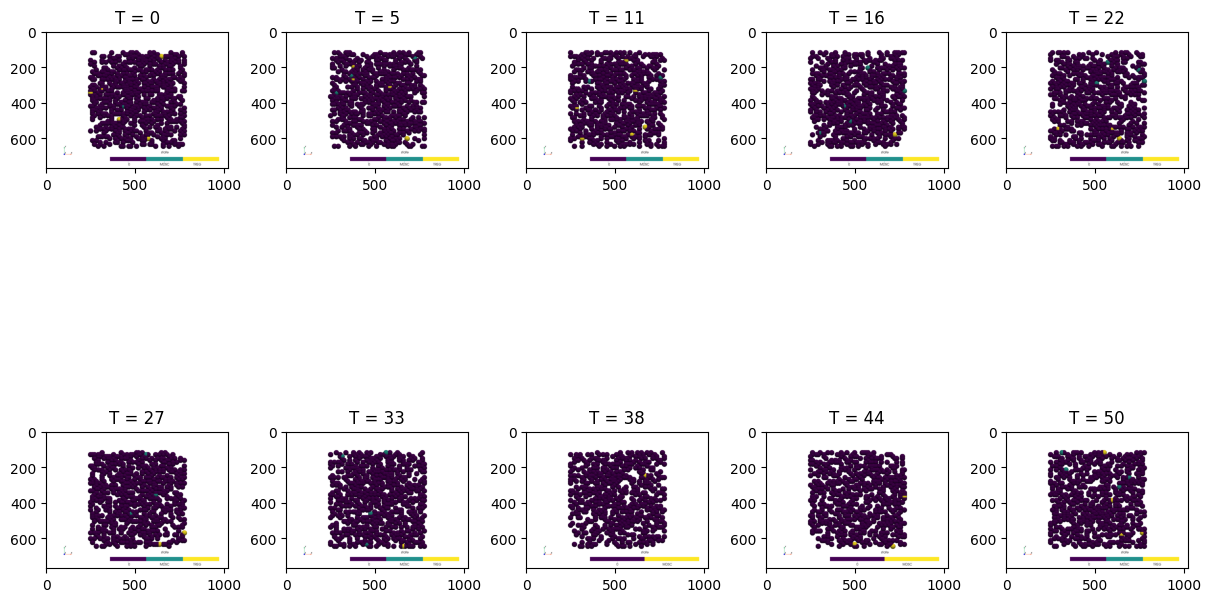

In [6]:
fig, axes = plt.subplots(2,5,figsize=(12,8),layout='constrained')
cnt = 0
for i, ax_row in enumerate(axes):
    for j, ax in enumerate(ax_row):
        p = pv.Plotter()
        p.add_mesh(clouds[cnt],scalars = 'state', point_size=30,render_points_as_spheres=True)
        p.add_axes()
        p.view_xy()
        img = p.screenshot(transparent_background=False)
        p.close()
        ax.imshow(img)
        ax.set_title('T = ' + str(ts[cnt]))
        cnt+=1
plt.savefig('Cancer cells.png')

In [7]:
substrates = np.zeros((50,50,10,10))
names = ['O2','IFN','IL2','IL10','TGFB','CCL2','ARGI','NO','IL12','VEGFA']
for i in range(10):
    for index, row in pdes[i].iterrows():
        x = row['x'].astype(np.int32)
        y = row['y'].astype(np.int32)
        values = row[names].to_numpy()
        substrates[y,x,:,i] = values
         

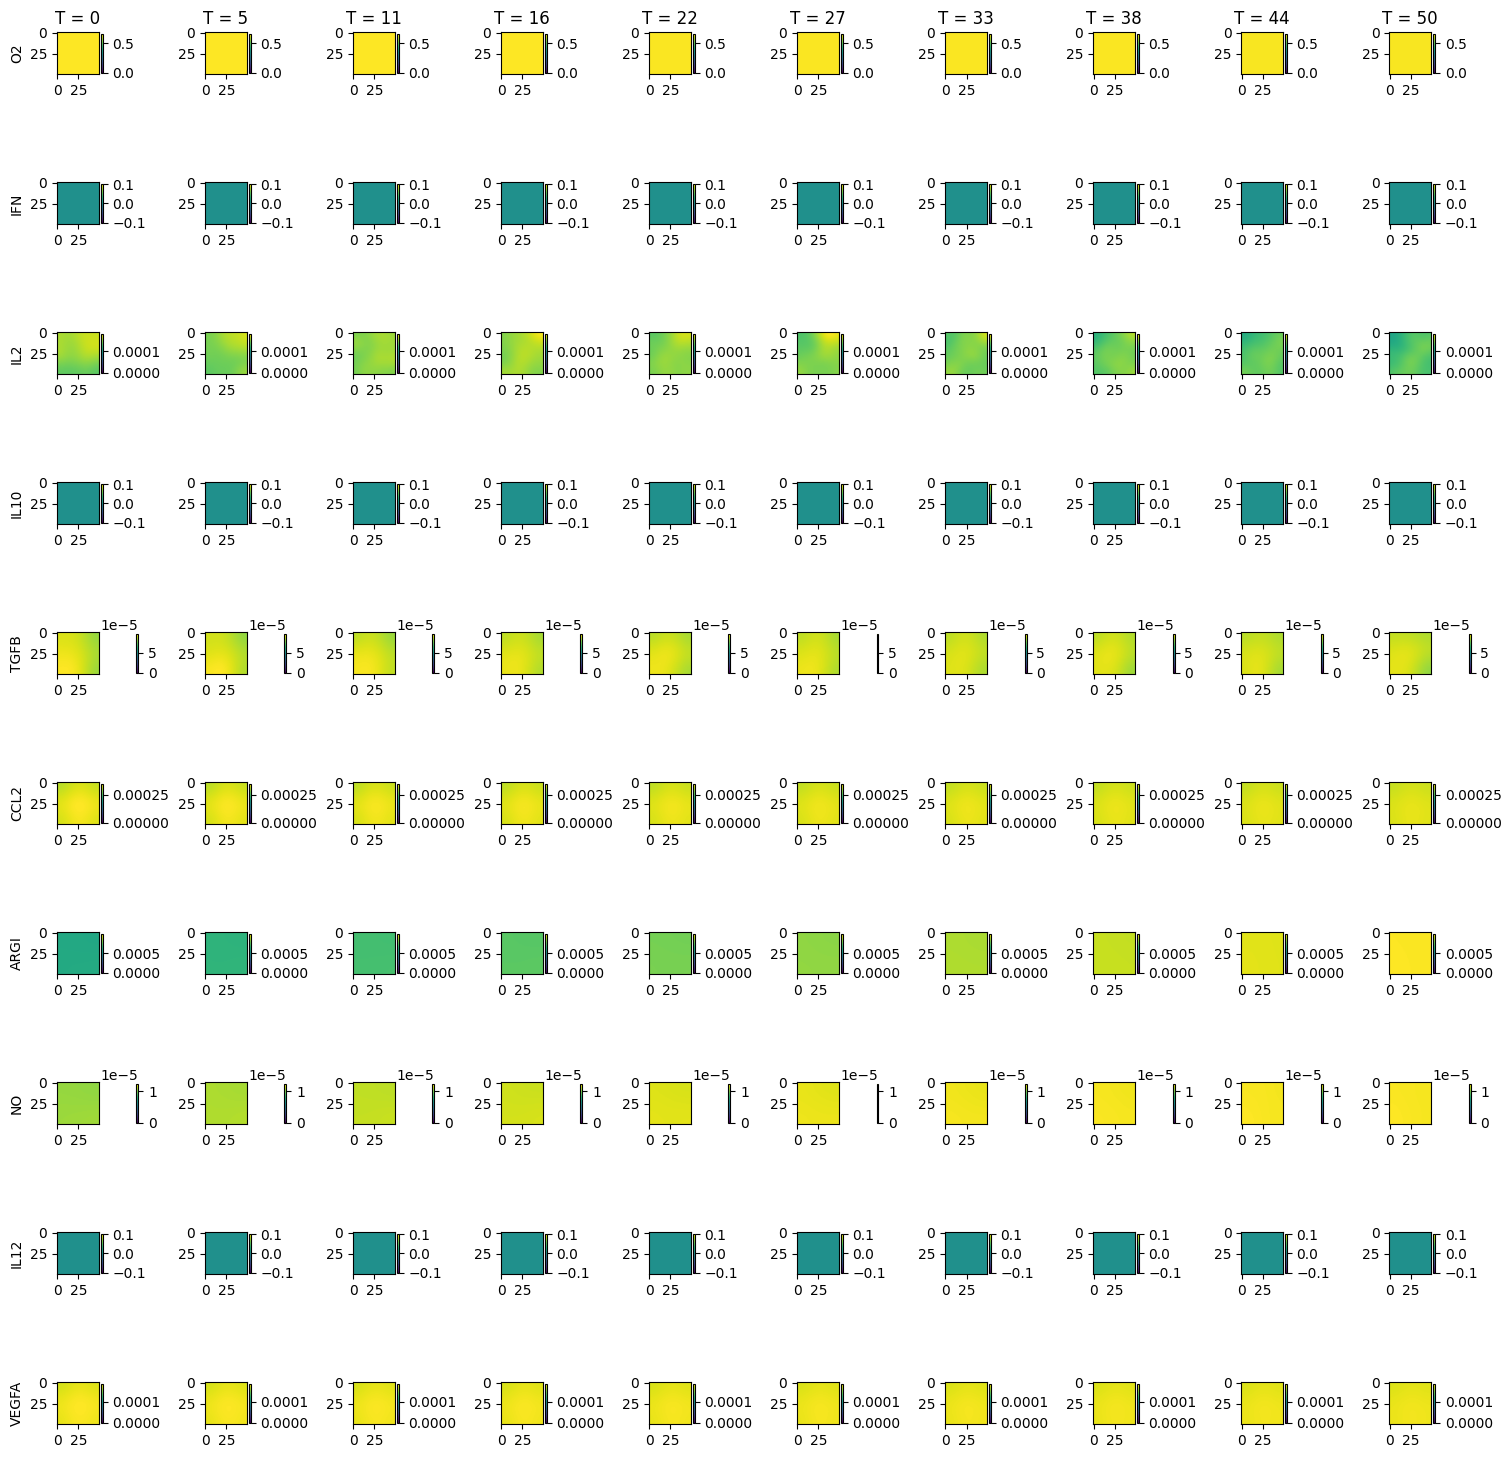

In [8]:
mins = np.min(np.min(np.min(substrates,axis=3),axis=0),axis=0)
maxes = np.max(np.max(np.max(substrates,axis=3),axis=0),axis=0)

fig, ax = plt.subplots(10,10,figsize=(15,15),layout='constrained')
for i in range(10):
    for j in range(10):
        im = ax[i][j].imshow(substrates[:,:,i,j], vmin = 0, vmax = maxes[i])
        fig.colorbar(im, ax=ax[i][j],fraction=0.046, pad=0.04)
        if j == 0:
            ax[i][j].set_ylabel(names[i])
        if i == 0:
            ax[i][j].set_title('T = ' + str(ts[j]))
            
plt.savefig('PDE proifles.png')


In [9]:
print((np.log(2)/0.5)*86400/600)

199.62638800126425
